# MAKİNE ÖĞRENMESİ - 201 

## 2.1 BASİT DOĞRUSAL REGRESYON MODELİ 

In [20]:
import pandas as pd
import os

if os.path.basename(os.getcwd()) != "mak_ogrenmesi":
    os.chdir("mak_ogrenmesi")

# Excel olarak okuyoruz
df = pd.read_excel("Advertising.csv.xlsx")

# Eğer veriler virgülle tek sütuna sıkıştıysa, onları pürüzsüzce 4 sütuna bölüyoruz
if df.shape[1] == 1:
    sutun_adi = df.columns[0]
    df = df[sutun_adi].str.split(",", expand=True)
    df.columns = ["Index", "TV", "radio", "newspaper", "sales"]
    df = df.drop(columns=["Index"])
    # Değerleri sayısal formata (float) çeviriyoruz
    df = df.astype(float)

df.head()


,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [21]:
df

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,9.7
197,177.0,9.3,6.4,12.8
198,283.6,42.0,66.2,25.5


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   radio      200 non-null    float64
 2   newspaper  200 non-null    float64
 3   sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


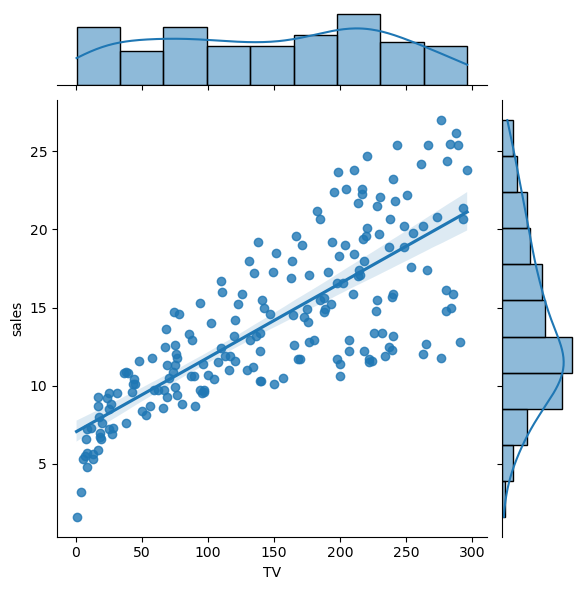

In [23]:
import seaborn as sns
sns.jointplot(x = "TV", y = "sales", data = df, kind = "reg");

In [24]:
from sklearn.linear_model import LinearRegression

In [25]:
X = df[["TV"]]

In [27]:
X.head()

,TV
0,230.1
1,44.5
2,17.2
3,151.5
4,180.8


In [28]:
y = df[["sales"]]

In [31]:
reg = LinearRegression()

In [33]:
model = reg.fit(X, y)

In [35]:
model

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [36]:
str(model)

'LinearRegression()'

In [37]:
dir(model)

['__abstractmethods__',
 '__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__sklearn_clone__',
 '__sklearn_tags__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abc_impl',
 '_build_request_for_signature',
 '_decision_function',
 '_doc_link_module',
 '_doc_link_template',
 '_doc_link_url_param_generator',
 '_estimator_type',
 '_get_default_requests',
 '_get_doc_link',
 '_get_metadata_request',
 '_get_param_names',
 '_get_params_html',
 '_html_repr',
 '_parameter_constraints',
 '_repr_html_',
 '_repr_html_inner',
 '_repr_mimebundle_',
 '_set_intercept',
 '_validate_params',
 'coef_',
 'copy_X',
 'feature_names_in_',

In [38]:
model.intercept_

array([7.03259355])

In [40]:
model.coef_

array([[0.04753664]])

In [42]:
#rkare
model.score(X, y)

0.611875050850071

### 2.2 Basit Doğrusal Regresyon Tahmin

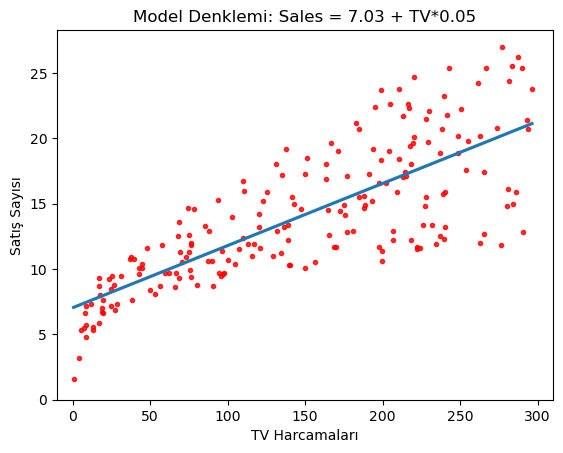

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt
g = sns.regplot(x = df["TV"], y = df["sales"], ci=None, scatter_kws={'color':'r', 's':9})
g.set_title("Model Denklemi: Sales = 7.03 + TV*0.05")
g.set_ylabel("Satış Sayısı")
g.set_xlabel("TV Harcamaları")
plt.xlim(-10,310)
plt.ylim(bottom=0);

Sales = 7.03 + 0.05*TV

In [46]:
7.03 + 0.05*165

15.280000000000001

In [48]:
model.predict([[165]])

C:\Users\hkoca\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[14.87613922]])

In [49]:
model.intercept_ + model.coef_*165

array([[14.87613922]])

In [50]:
yeni_veri = [[5],[15],[20]]

In [51]:
model.predict(yeni_veri)

C:\Users\hkoca\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[7.27027675],
       [7.74564316],
       [7.98332636]])

In [53]:
model.predict([[400]])

C:\Users\hkoca\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[26.04724972]])

### 2.3 Basit Doğrusal Regresyon Artıklar

MSE: Hata Kareler Ortalaması


RMSE: Hata Kareler Ortalamasının Karekökü

In [55]:
y.head()

,sales
0,22.1
1,10.4
2,9.3
3,18.5
4,12.9


In [56]:
model.predict(X)[0:6]

array([[17.97077451],
       [ 9.14797405],
       [ 7.85022376],
       [14.23439457],
       [15.62721814],
       [ 7.44616232]])

In [59]:
gercek_y =y[0:10]

In [60]:
tahmin_edilen_y = pd.DataFrame(model.predict(X)[0:10])

In [61]:
hatalar = pd.concat([gercek_y, tahmin_edilen_y], axis=1)

In [64]:
hatalar.columns = ["gercek_y", "tahmin_edilen_y"]

In [65]:
hatalar

,gercek_y,tahmin_edilen_y
0,22.1,17.970775
1,10.4,9.147974
2,9.3,7.850224
3,18.5,14.234395
4,12.9,15.627218
5,7.2,7.446162
6,11.8,9.765950
7,13.2,12.746498
8,4.8,7.441409
9,10.6,16.530414


In [66]:
hatalar["hata"] = hatalar["gercek_y"] - hatalar["tahmin_edilen_y"]

In [67]:
hatalar

,gercek_y,tahmin_edilen_y,hata
0,22.1,17.970775,4.129225
1,10.4,9.147974,1.252026
2,9.3,7.850224,1.449776
3,18.5,14.234395,4.265605
4,12.9,15.627218,-2.727218
5,7.2,7.446162,-0.246162
6,11.8,9.765950,2.034050
7,13.2,12.746498,0.453502
8,4.8,7.441409,-2.641409
9,10.6,16.530414,-5.930414


In [68]:
hatalar["hata_kareler"] = hatalar["hata"]**2

In [69]:
hatalar

,gercek_y,tahmin_edilen_y,hata,hata_kareler
0,22.1,17.970775,4.129225,17.050503
1,10.4,9.147974,1.252026,1.567569
2,9.3,7.850224,1.449776,2.101851
3,18.5,14.234395,4.265605,18.195390
4,12.9,15.627218,-2.727218,7.437719
5,7.2,7.446162,-0.246162,0.060596
6,11.8,9.765950,2.034050,4.137358
7,13.2,12.746498,0.453502,0.205664
8,4.8,7.441409,-2.641409,6.977040
9,10.6,16.530414,-5.930414,35.169814


In [71]:
import numpy as np
np.mean(hatalar["hata_kareler"])

np.float64(9.290350329638105)

## 3.1 ÇOKLU DOĞRUSAL REGRESYON MODELİ

In [6]:
import pandas as pd
import os

if os.path.basename(os.getcwd()) != "mak_ogrenmesi":
    os.chdir("mak_ogrenmesi")

# Excel olarak okuyoruz
df = pd.read_excel("Advertising.csv.xlsx")

# Eğer veriler virgülle tek sütuna sıkıştıysa, onları pürüzsüzce 4 sütuna bölüyoruz
if df.shape[1] == 1:
    sutun_adi = df.columns[0]
    df = df[sutun_adi].str.split(",", expand=True)
    df.columns = ["Index", "TV", "radio", "newspaper", "sales"]
    df = df.drop(columns=["Index"])
    # Değerleri sayısal formata (float) çeviriyoruz
    df = df.astype(float)

df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [7]:
X = df.drop('sales', axis=1)
y = df[["sales"]]

In [8]:
y.head()

,sales
0,22.1
1,10.4
2,9.3
3,18.5
4,12.9


In [9]:
X.head()

,TV,radio,newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4


#### Statsmodel ile model kurmak

In [10]:
import statsmodels.api as sm

In [11]:
lm = sm.OLS(y, X)

In [12]:
model = lm.fit()

In [13]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                  sales   R-squared (uncentered):                   0.982
Model:                            OLS   Adj. R-squared (uncentered):              0.982
Method:                 Least Squares   F-statistic:                              3566.
Date:                Mon, 10 Aug 2026   Prob (F-statistic):                   2.43e-171
Time:                        18:06:00   Log-Likelihood:                         -423.54
No. Observations:                 200   AIC:                                      853.1
Df Residuals:                     197   BIC:                                      863.0
Df Model:                           3                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
TV             0.0538      0.001     40.507      0.000       0.051       0.056
radio          0.2222      0.009     23.595      0.000       0.204       0.241
newspaper      0.0168      0.007      2.517      0.013       0.004       0.030
==============================================================================
Omnibus:                        5.982   Durbin-Watson:                   2.038
Prob(Omnibus):                  0.050   Jarque-Bera (JB):                7.039
Skew:                          -0.232   Prob(JB):                       0.0296
Kurtosis:                       3.794   Cond. No.                         12.6
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

#### Scikit learn ile model kurmak

In [14]:
from sklearn.linear_model import LinearRegression
lm = LinearRegression()

In [15]:
model = lm.fit(X,y)

In [41]:
model.intercept_

array([2.93888937])

In [40]:
model.coef_

array([[ 0.04576465,  0.18853002, -0.00103749]])

### 3.2 Çoklu Doğrusal Regresyon Tahmin

#### Sales = 2.94 + 0.04* TV + radio* 0.19 - newspaper*0.001

In [42]:
2.94 + 0.04* 30 + 10* 0.19 - 40*0.001

5.999999999999999

In [43]:
yeni_veri = [[30],[10],[40]]

In [44]:
import pandas as pd
yeni_veri = pd.DataFrame(yeni_veri).T

In [45]:
yeni_veri

,0,1,2
0,30,10,40


In [33]:
model.predict(yeni_veri)

C:\Users\hkoca\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[6.15562918]])

In [70]:
yeni_veri1 = [[300],[120],[400]]

In [75]:
yeni_veri1 = pd.DataFrame(yeni_veri1).T
yeni_veri1

,0,1,2
0,300,120,400


In [76]:
model.predict(yeni_veri1)

C:\Users\hkoca\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[39.44183917]])

In [49]:
from sklearn.metrics import mean_squared_error

In [50]:
y.head()

,sales
0,22.1
1,10.4
2,9.3
3,18.5
4,12.9


In [51]:
model.predict(X)[0:10]

array([[20.52397441],
       [12.33785482],
       [12.30767078],
       [17.59782951],
       [13.18867186],
       [12.47834763],
       [11.72975995],
       [12.12295317],
       [ 3.72734086],
       [12.55084872]])

In [52]:
MSE = mean_squared_error(y, model.predict(X))
MSE

2.784126314510936

In [53]:
import numpy as np
RMSE = np.sqrt(MSE)
RMSE

np.float64(1.6685701407225697)

### 3.3 Çoklu Doğrusal Regresyon Model Tuning

In [54]:
X.head()

,TV,radio,newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4


In [55]:
y.head()

,sales
0,22.1
1,10.4
2,9.3
3,18.5
4,12.9


In [56]:
#sinama seti
from sklearn.model_selection import train_test_split

In [77]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state=1)

In [78]:
X_train.head()

,TV,radio,newspaper
108,13.1,0.4,25.6
107,90.4,0.3,23.2
189,18.7,12.1,23.4
14,204.1,32.9,46.0
56,7.3,28.1,41.4


In [79]:
y_train.head()

,sales
108,5.3
107,8.7
189,6.7
14,19.0
56,5.5


In [80]:
X_test.head()

,TV,radio,newspaper
58,210.8,49.6,37.7
40,202.5,22.3,31.6
34,95.7,1.4,7.4
102,280.2,10.1,21.4
184,253.8,21.3,30.0


In [81]:
y_test.head()

,sales
58,23.8
40,16.6
34,9.5
102,14.8
184,17.6


In [82]:
lm = LinearRegression()
model = lm.fit(X_train, y_train)

In [83]:
#egitim hatasi
np.sqrt(mean_squared_error(y_train, model.predict(X_train)))

np.float64(1.736902590147092)

In [84]:
#test hatasi
np.sqrt(mean_squared_error(y_test, model.predict(X_test)))

np.float64(1.4113417558581587)

In [85]:
#k-katlı cross validation

In [86]:
from sklearn.model_selection import cross_val_score

In [87]:
cross_val_score(model, X_train, y_train, cv = 10, scoring = "neg_mean_squared_error")

array([-1.62375953, -3.81875608, -3.43828142, -2.27748673, -7.25325414,
       -1.88303708, -2.80517715, -3.68594486, -1.12810834, -3.96330989])

In [88]:
# cv ile mse
np.mean(-cross_val_score(model, X_train, y_train, cv = 10, scoring = "neg_mean_squared_error"))

np.float64(3.187711520944357)

In [89]:
# cv ile rmse
np.sqrt(np.mean(-cross_val_score(model, X_train, y_train, cv = 10, scoring = "neg_mean_squared_error")))

np.float64(1.7854163438661463)

In [90]:
#cv rmse
np.sqrt(np.mean(-cross_val_score(model, X, y, cv = 10, scoring = "neg_mean_squared_error")))

np.float64(1.7492763126843383)

## 4. RIDGE REGRESYON MODELİ

#### Gerekli Kütüphaneler

In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn import model_selection
import matplotlib.pyplot as plt
from sklearn.linear_model import RidgeCV

#### Gerekli Kütüphaneler

In [9]:
df = pd.read_csv("Hitters.csv")
df = df.dropna()
dms = pd.get_dummies(df[['League','Division','NewLeague']], dtype=int)
y = df["Salary"]
X_ = df.drop(['Salary','League','Division','NewLeague'], axis =1).astype('float64')
X = pd.concat([X_, dms[['League_N','Division_W','NewLeague_N']]], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [10]:
df.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N
5,594,169,4,74,51,35,11,4408,1133,19,501,336,194,A,W,282,421,25,750.0,A


In [11]:
df.shape

(263, 20)

In [19]:
ridge_model = Ridge(alpha = 5).fit(X_train, y_train)

In [20]:
ridge_model

,alpha,5
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [21]:
ridge_model.coef_

array([ -1.81040449,   8.87872786,   7.12487047,  -3.31713488,
        -2.01162162,   5.40691525,   7.25828404,  -0.13033385,
        -0.25425913,  -0.71109275,   1.81452   ,   0.77083457,
        -0.6768975 ,   0.26211894,   0.2646614 ,  -0.36947934,
        76.19519054, -90.15523668, -16.00453535])

In [22]:
ridge_model.intercept_

np.float64(-3.4251968687156022)

In [25]:
np.linspace(10,-2,100)*0.5

array([ 5.        ,  4.93939394,  4.87878788,  4.81818182,  4.75757576,
        4.6969697 ,  4.63636364,  4.57575758,  4.51515152,  4.45454545,
        4.39393939,  4.33333333,  4.27272727,  4.21212121,  4.15151515,
        4.09090909,  4.03030303,  3.96969697,  3.90909091,  3.84848485,
        3.78787879,  3.72727273,  3.66666667,  3.60606061,  3.54545455,
        3.48484848,  3.42424242,  3.36363636,  3.3030303 ,  3.24242424,
        3.18181818,  3.12121212,  3.06060606,  3.        ,  2.93939394,
        2.87878788,  2.81818182,  2.75757576,  2.6969697 ,  2.63636364,
        2.57575758,  2.51515152,  2.45454545,  2.39393939,  2.33333333,
        2.27272727,  2.21212121,  2.15151515,  2.09090909,  2.03030303,
        1.96969697,  1.90909091,  1.84848485,  1.78787879,  1.72727273,
        1.66666667,  1.60606061,  1.54545455,  1.48484848,  1.42424242,
        1.36363636,  1.3030303 ,  1.24242424,  1.18181818,  1.12121212,
        1.06060606,  1.        ,  0.93939394,  0.87878788,  0.81

In [24]:
lambdalar = 10**np.linspace(10,-2,100)*0.5

In [26]:
lambdalar

array([5.00000000e+09, 3.78231664e+09, 2.86118383e+09, 2.16438064e+09,
       1.63727458e+09, 1.23853818e+09, 9.36908711e+08, 7.08737081e+08,
       5.36133611e+08, 4.05565415e+08, 3.06795364e+08, 2.32079442e+08,
       1.75559587e+08, 1.32804389e+08, 1.00461650e+08, 7.59955541e+07,
       5.74878498e+07, 4.34874501e+07, 3.28966612e+07, 2.48851178e+07,
       1.88246790e+07, 1.42401793e+07, 1.07721735e+07, 8.14875417e+06,
       6.16423370e+06, 4.66301673e+06, 3.52740116e+06, 2.66834962e+06,
       2.01850863e+06, 1.52692775e+06, 1.15506485e+06, 8.73764200e+05,
       6.60970574e+05, 5.00000000e+05, 3.78231664e+05, 2.86118383e+05,
       2.16438064e+05, 1.63727458e+05, 1.23853818e+05, 9.36908711e+04,
       7.08737081e+04, 5.36133611e+04, 4.05565415e+04, 3.06795364e+04,
       2.32079442e+04, 1.75559587e+04, 1.32804389e+04, 1.00461650e+04,
       7.59955541e+03, 5.74878498e+03, 4.34874501e+03, 3.28966612e+03,
       2.48851178e+03, 1.88246790e+03, 1.42401793e+03, 1.07721735e+03,
      

In [28]:
ridge_model = Ridge()
katsayilar = []

for i in lambdalar:
    ridge_model.set_params(alpha = i)
    ridge_model.fit(X_train, y_train)
    katsayilar.append(ridge_model.coef_)

In [29]:
katsayilar

[array([ 1.08705828e-03,  3.59972026e-04,  5.52181027e-05,  1.92813177e-04,
         1.96696069e-04,  1.59478501e-04,  2.78199599e-05,  1.78978518e-02,
         5.28448603e-03,  6.33684784e-04,  2.78574434e-03,  2.70578331e-03,
         1.95710128e-03,  1.87423190e-03,  1.54040667e-04,  2.97933111e-06,
         2.39984989e-07, -1.51804510e-06,  3.31089982e-07]),
 array([ 1.41677983e-03,  4.69820454e-04,  7.18242293e-05,  2.52218183e-04,
         2.55763476e-04,  2.07728851e-04,  3.41731833e-05,  2.22675231e-02,
         6.58971645e-03,  7.96723486e-04,  3.48283639e-03,  3.38849662e-03,
         2.44474193e-03,  2.46055074e-03,  2.00411447e-04,  4.05879985e-06,
         3.06791363e-07, -2.00697735e-06,  4.22750663e-07]),
 array([ 1.84180994e-03,  6.11797854e-04,  9.31516430e-05,  3.29313865e-04,
         3.31574150e-04,  2.69862282e-04,  4.11993224e-05,  2.73092348e-02,
         8.10613246e-03,  9.90615632e-04,  4.29892819e-03,  4.19154557e-03,
         3.01420413e-03,  3.22598807e-03, 

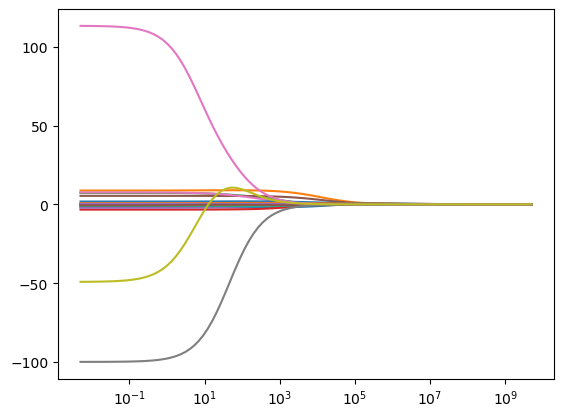

In [31]:
ax = plt.gca()
ax.plot(lambdalar, katsayilar)
ax.set_xscale("log")

### 4.1 RIDGE REGRESYON TAHMİN

In [36]:
ridge_model = Ridge().fit(X_train, y_train)

In [37]:
y_pred = ridge_model.predict(X_train)

In [38]:
y_pred[0:10]

array([ 376.25245449,  803.38498121,  496.17669652,  112.69554648,
        427.60020221, 1003.6309402 ,  153.45713944,  361.33880956,
        483.29143665,  916.91439669])

In [39]:
y_train[0:10]

183     125.0
229    1940.0
286     940.0
102     375.0
153     100.0
320     960.0
135      90.0
213     100.0
308     750.0
161     657.0
Name: Salary, dtype: float64

In [47]:
#train hatasi
RMSE = np.sqrt(mean_squared_error(y_train, y_pred))
RMSE

np.float64(289.34470696006565)

In [44]:
from sklearn.model_selection import cross_val_score

In [45]:
(np.mean(-cross_val_score(ridge_model, X_train, y_train, cv = 10, scoring = "neg_mean_squared_error")))

np.float64(123477.15188321724)

In [46]:
np.sqrt(np.mean(-cross_val_score(ridge_model, X_train, y_train, cv = 10, scoring = "neg_mean_squared_error")))

np.float64(351.39315856063166)

In [48]:
#test hatasi
y_pred = ridge_model.predict(X_test)

In [49]:
RMSE = np.sqrt(mean_squared_error(y_test, y_pred))
RMSE

np.float64(356.80829057302384)

### 4.2 RIDGE REGRESYON MODEL TUNING

##### Neden Model Tuning ?

In [50]:
ridge_model = Ridge().fit(X_train, y_train)
y_pred = ridge_model.predict(X_test)
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(356.80829057302384)

In [52]:
ridge_model = Ridge(100).fit(X_train, y_train)
y_pred = ridge_model.predict(X_test)
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(357.8154668279845)

In [53]:
ridge_model = Ridge(1000).fit(X_train, y_train)
y_pred = ridge_model.predict(X_test)
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(358.5637914255955)

In [54]:
ridge_model = Ridge(1).fit(X_train, y_train)
y_pred = ridge_model.predict(X_test)
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(356.80829057302384)

In [57]:
lambdalar1 = np.random.randint(0,1000,100)

In [58]:
lambdalar2 = 10**np.linspace(10, -2, 100)*0.5

In [66]:
ridgecv = RidgeCV(alphas = lambdalar2, scoring = "neg_mean_squared_error", cv = 10)
ridgecv.fit(X_train, y_train)

,alphas,array([5.0000...00000000e-03])
,fit_intercept,True
,scoring,'neg_mean_squared_error'
,cv,10
,gcv_mode,None
,store_cv_results,False
,alpha_per_target,False


In [70]:
print(ridgecv)


RidgeCV(alphas=array([5.00000000e+09, 3.78231664e+09, 2.86118383e+09, 2.16438064e+09,
       1.63727458e+09, 1.23853818e+09, 9.36908711e+08, 7.08737081e+08,
       5.36133611e+08, 4.05565415e+08, 3.06795364e+08, 2.32079442e+08,
       1.75559587e+08, 1.32804389e+08, 1.00461650e+08, 7.59955541e+07,
       5.74878498e+07, 4.34874501e+07, 3.28966612e+07, 2.48851178e+07,
       1.88246790e+07, 1.42401793e+0...
       3.06795364e+00, 2.32079442e+00, 1.75559587e+00, 1.32804389e+00,
       1.00461650e+00, 7.59955541e-01, 5.74878498e-01, 4.34874501e-01,
       3.28966612e-01, 2.48851178e-01, 1.88246790e-01, 1.42401793e-01,
       1.07721735e-01, 8.14875417e-02, 6.16423370e-02, 4.66301673e-02,
       3.52740116e-02, 2.66834962e-02, 2.01850863e-02, 1.52692775e-02,
       1.15506485e-02, 8.73764200e-03, 6.60970574e-03, 5.00000000e-03]),
        cv=10, scoring='neg_mean_squared_error')


In [74]:
ridgecv.alpha_

np.float64(1526927.7544167063)

In [81]:
# 1. Eski scikit-learn 'normalize=True' parametresinin tam matematiksel formülü
X_mean = X_train.mean(axis=0)
X_centered = X_train - X_mean
X_scale = np.sqrt(np.sum(X_centered**2, axis=0))
X_train_scaled = X_centered / X_scale

# 2. Modeli bu orijinal ölçekle eğitiyoruz
ridgecv_hocam = RidgeCV(alphas = lambdalar2, scoring = "neg_mean_squared_error", cv = 10)
ridgecv_hocam.fit(X_train_scaled, y_train)
ridgecv_hocam.alpha_



np.float64(0.7599555414764666)

In [82]:
##final modeli

In [83]:
ridge_tuned = Ridge(alpha = ridgecv.alpha_).fit(X_train, y_train)

In [84]:
y_pred = ridge_model.predict(X_test)
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(356.80829057302384)

## 5.LASSO REGRESYON MODELİ¶

#### Gerekli Kütüphaneler

In [107]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn import model_selection
import matplotlib.pyplot as plt
from sklearn.linear_model import RidgeCV

#### Veri Seti

In [108]:
df = pd.read_csv("Hitters.csv")
df = df.dropna()
dms = pd.get_dummies(df[['League','Division','NewLeague']], dtype=int)
y = df["Salary"]
X_ = df.drop(['Salary','League','Division','NewLeague'], axis =1).astype('float64')
X = pd.concat([X_, dms[['League_N','Division_W','NewLeague_N']]], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [88]:
df.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N
5,594,169,4,74,51,35,11,4408,1133,19,501,336,194,A,W,282,421,25,750.0,A


In [109]:
df.shape

(263, 20)

In [110]:
from sklearn.linear_model import Lasso
lasso_model = Lasso().fit(X_train, y_train)

C:\Users\hkoca\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.257e+06, tolerance: 3.899e+03
  model = cd_fast.enet_coordinate_descent(


In [111]:
lasso_model

,alpha,1.0
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [112]:
lasso_model.intercept_

np.float64(-5.587450677335255)

In [113]:
lasso_model.coef_

array([-1.74875691e+00,  8.59204135e+00,  6.67993798e+00, -3.06715333e+00,
       -1.91843070e+00,  5.32372890e+00,  8.39184117e+00, -1.63172447e-01,
       -8.22311277e-02, -3.93602861e-01,  1.71118530e+00,  6.55730545e-01,
       -6.48379405e-01,  2.59815358e-01,  2.73041157e-01, -4.41440454e-01,
        8.54474011e+01, -9.59701213e+01, -2.13086605e+01])

In [96]:
#farkli lambda degerlerine karşilik katsayilar

In [122]:
lasso = Lasso()
coefs = []
alphas = np.random.randint(0,100000,100)
for a in alphas:
    lasso.set_params(alpha = a)
    lasso.fit(X_train, y_train)
    coefs.append(lasso.coef_)

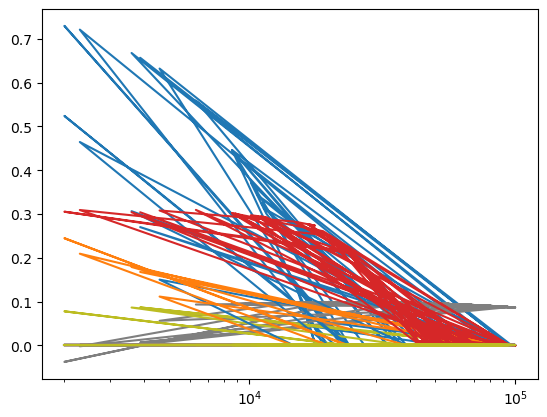

In [123]:
ax = plt.gca()
ax.plot(alphas, coefs)
ax.set_xscale("log")

In [126]:
#lambdalar2 li örnek:
lasso = Lasso()
coefs = []
alphas = 10**np.linspace(10, -2, 100)*0.5
for a in alphas:
    lasso.set_params(alpha = a)
    lasso.fit(X_train, y_train)
    coefs.append(lasso.coef_)

C:\Users\hkoca\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.470e+03, tolerance: 3.899e+03
  model = cd_fast.enet_coordinate_descent(
C:\Users\hkoca\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.540e+03, tolerance: 3.899e+03
  model = cd_fast.enet_coordinate_descent(
C:\Users\hkoca\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.002e+03, toleranc

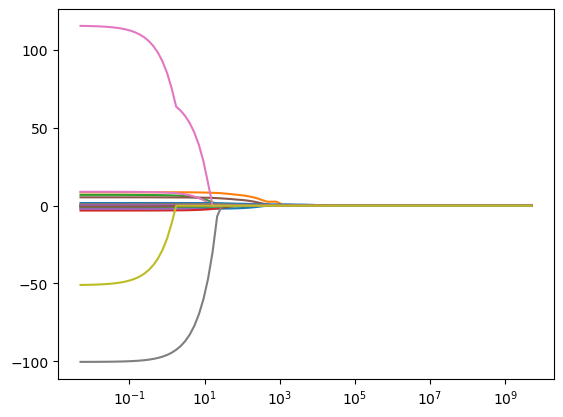

In [127]:
#lambdalar2 li grafik:
ax = plt.gca()
ax.plot(alphas, coefs)
ax.set_xscale("log")

### 5.1 LASSO REGRESYON TAHMİN

In [128]:
lasso_model

,alpha,1.0
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [129]:
lasso_model.predict(X_train)[0:5]

array([377.26270596, 786.51524513, 495.14140718, 117.19492966,
       429.04228506])

In [130]:
lasso_model.predict(X_test)[0:5]

array([ 609.18826367,  696.96810702, 1009.06157391,  412.22773375,
        409.25851712])

In [133]:
y_pred = lasso_model.predict(X_test)

In [135]:
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(356.0975884554033)

In [136]:
r2_score(y_test, y_pred )

0.4142279813236618

### 5.1 LASSO REGRESYON MODEL TUNING

In [ ]:
alphas = 10**np.linspace(10, -2, 100)*0.5

In [138]:
from sklearn.linear_model import LassoCV
lasso_cv_model = LassoCV(cv = 10, max_iter= 100000).fit(X_train, y_train)

In [139]:
lasso_cv_model.alpha_

np.float64(563.4670501833853)

In [141]:
lasso_tuned = Lasso().set_params(alpha = lasso_cv_model.alpha_).fit(X_train, y_train)

In [142]:
y_pred = lasso_tuned.predict(X_test)

In [145]:
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(373.59572250697937)

In [150]:
##alpha farklı deneyelim:
alphas = 10**np.linspace(10, -2, 100)*0.5
lasso_cv_model = LassoCV(alphas = alphas, cv = 10, max_iter= 100000).fit(X_train, y_train)
lasso_tuned = Lasso().set_params(alpha = lasso_cv_model.alpha_).fit(X_train, y_train)
y_pred = lasso_tuned.predict(X_test)
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(363.6832708037447)

In [153]:
#tune edilmıs lasso modelinin katsayılarını degıskenlerin ismiyle getirdik, katsayısı 0 olanlar anlamsız degıskenler oldu..

pd.Series(lasso_tuned.coef_, index = X_train.columns)

AtBat         -1.052276
Hits           5.342648
HmRun          0.000000
Runs           0.000000
RBI            0.000000
Walks          2.640006
Years          0.000000
CAtBat        -0.174125
CHits          0.249805
CHmRun        -0.000000
CRuns          1.035075
CRBI           0.469281
CWalks        -0.186771
PutOuts        0.272541
Assists        0.170528
Errors        -0.000000
League_N       0.000000
Division_W    -0.000000
NewLeague_N    0.000000
dtype: float64

## 6.ELASTICNET REGRESYON MODEL ve TAHMİN

#### Gerekli Kütüphaneler

In [154]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn import model_selection
import matplotlib.pyplot as plt
from sklearn.linear_model import RidgeCV

#### Veri Seti

In [155]:
df = pd.read_csv("Hitters.csv")
df = df.dropna()
dms = pd.get_dummies(df[['League','Division','NewLeague']], dtype=int)
y = df["Salary"]
X_ = df.drop(['Salary','League','Division','NewLeague'], axis =1).astype('float64')
X = pd.concat([X_, dms[['League_N','Division_W','NewLeague_N']]], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [156]:
enet_model = ElasticNet().fit(X_train, y_train)

C:\Users\hkoca\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.488e+06, tolerance: 3.899e+03
  model = cd_fast.enet_coordinate_descent(


In [157]:
enet_model.coef_

array([ -1.86256172,   8.70489065,   5.10426375,  -2.89875799,
        -1.28642985,   5.24343682,   6.04480276,  -0.14701495,
        -0.21566628,  -0.7897201 ,   1.80813117,   0.80914508,
        -0.61262382,   0.26816203,   0.27172387,  -0.36530729,
        19.2186222 , -31.16586592,   8.98369938])

In [158]:
enet_model.intercept_

np.float64(-6.465955602112899)

In [159]:
#tahmin
enet_model.predict(X_train)[0:10]

array([325.74706292, 776.06632333, 522.86508419, 107.64091955,
       449.03139566, 997.76095723,  99.78828622, 311.33763086,
       418.50335021, 879.9502608 ])

In [160]:
enet_model.predict(X_test)[0:10]

array([ 577.79111731,  617.33202224, 1031.39113156,  364.95861575,
        489.51894393,  300.74185842,  604.522666  ,  465.34678732,
        901.44473965,  703.20357123])

In [161]:
y_pred = enet_model.predict(X_test)

In [162]:
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(357.16765481812456)

In [167]:
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

0.4107022246932688

### 6.1 ELASTICNET REGRESYON MODEL TUNING

In [169]:
from sklearn.linear_model import ElasticNetCV
enet_cv_model = ElasticNetCV(cv = 10).fit(X_train, y_train)

In [170]:
enet_cv_model.alpha_

np.float64(5230.764736479864)

In [171]:
enet_cv_model.intercept_

np.float64(-38.519405583943126)

In [172]:
enet_cv_model.coef_

array([ 0.62845434,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        , -0.        ,  0.        ,  0.09788752,  0.        ,
        0.27265769,  0.19270075,  0.00758665,  0.3106529 ,  0.        ,
       -0.        ,  0.        , -0.        ,  0.        ])

In [173]:
#final model

In [174]:
enet_tuned = ElasticNet(alpha = enet_cv_model.alpha_).fit(X_train, y_train)

In [175]:
y_pred = enet_tuned.predict(X_test)

In [176]:
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(394.15280563218795)

In [177]:
?ElasticNet

Init signature:
ElasticNet(
    alpha=1.0,
    *,
    l1_ratio=0.5,
    fit_intercept=True,
    precompute=False,
    max_iter=1000,
    copy_X=True,
    tol=0.0001,
    warm_start=False,
    positive=False,
    random_state=None,
    selection='cyclic',
)
Docstring:     
Linear regression with combined L1 and L2 priors as regularizer.

Minimizes the objective function::

        1 / (2 * n_samples) * ||y - Xw||^2_2
        + alpha * l1_ratio * ||w||_1
        + 0.5 * alpha * (1 - l1_ratio) * ||w||^2_2

If you are interested in controlling the L1 and L2 penalty
separately, keep in mind that this is equivalent to::

        a * ||w||_1 + 0.5 * b * ||w||_2^2

where::

        alpha = a + b and l1_ratio = a / (a + b)

The parameter l1_ratio corresponds to alpha in the glmnet R package while
alpha corresponds to the lambda parameter in glmnet. Specifically, l1_ratio
= 1 is the lasso penalty. Currently, l1_ratio <= 0.01 is not reliable,
unless you supply your own sequence of alpha.

Read mo

In [178]:
##alpha farklı deneyelim:
alphas = 10**np.linspace(10, -2, 100)*0.5
enet_cv_model = ElasticNetCV(alphas = alphas,cv = 10).fit(X_train, y_train)

C:\Users\hkoca\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.250e+03, tolerance: 3.241e+03
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\hkoca\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.337e+03, tolerance: 3.241e+03
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\hkoca\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.751e+03

In [179]:
enet_cv_model.alpha_

np.float64(5748.784976988678)

In [180]:
enet_cv_model.intercept_

np.float64(-31.46312122564109)

In [181]:
enet_cv_model.coef_

array([ 0.61111381,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        , -0.        ,  0.        ,  0.11212622,  0.        ,
        0.25252702,  0.18656722,  0.00444355,  0.30988823,  0.        ,
       -0.        ,  0.        , -0.        ,  0.        ])

In [182]:
enet_tuned = ElasticNet(alpha = enet_cv_model.alpha_).fit(X_train, y_train)

In [183]:
y_pred = enet_tuned.predict(X_test)

In [184]:
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(393.9753065850553)